<a href="https://colab.research.google.com/github/matthewhawksby/colabnotebooks/blob/main/LeftTemporalLocalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# meg_classification_models.py
import os
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import glob


In [ ]:
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/MNE/bci-main/src/data/"
TSV_PATH = "/content/drive/MyDrive/Colab Notebooks/MNE/bci-main/stimuli/demo/*.tsv"


import helper

all_data = helper.stimuli_load(TSV_PATH)
metadata = pd.DataFrame.from_dict(all_data, orient='index').reset_index()
metadata_df.rename(columns={"index": "stimulus"}, inplace=True)

csv_files = sorted(glob.glob(DATA_DIR + "M*_main_*.csv"))

def build_alignment_df(csv_path):
    df = pd.read_csv(csv_path)

    df["audio_file"] = df["audio_file"].str.replace("\\", "/", regex=False)
    df["audio_file"] = df["audio_file"].str.replace("../", "../", regex=False)

    df = df.merge(meta_df, how="left", left_on="audio_file", right_on="stimulus")

    df["global_onset"] = df["presentation.started"] + df["trigger_word_on.started"]

    df["response_clean"] = pd.to_numeric(df["buttonBox_2.keys"], errors='coerce').fillna(-1).astype(int)

    df["speaker_type"] = df["speaker"].apply(
        lambda s: "bot" if s in {"bot", "bot2"} else ("human" if pd.notna(s) else None)
    )

    def compute_resp_correct(row):
        if row["response_clean"] == -1 or pd.isna(row["tgt_sound"]) or pd.isna(row["sibilants"]):
            return None
        options = ["f", "θ"] if row["sibilants"] == "nonsibilant" else ["s", "ʃ"]
        if 0 <= row["response_clean"] < len(options):
            return row["tgt_sound"] == options[row["response_clean"]]
        return None

    df["resp_correct"] = df.apply(compute_resp_correct, axis=1)

    # Is it necessary to check for valid trials here?
    valid_df = df[df["response_clean"] != -1].copy()
    valid_df = valid_df.sort_values("global_onset").reset_index(drop=True)

    print(f"{csv_path.split('/')[-1]} → {len(valid_df)} valid trials")
    return valid_df

# --- Build array of aligned dataframes ---
alignment_dfs = [build_alignment_df(path) for path in csv_files]


/content/drive/MyDrive/Colab Notebooks/MNE/bci-main/src/helper.py
Trials in valid DataFrame: 656


,thisN,thisTrialN,thisRepN,key_resp.keys,buttonBox_2.keys,buttonBox_2.rt,buttonBox_2.duration,key_resp_3.keys,key_resp_3.rt,key_resp_3.duration,...,perplexity,word_pair,wav_onset,wav_offset,tgt_word_onset,tgt_word_offset,global_onset,response_clean,speaker_type,resp_correct
0,0.0,0.0,0.0,NaN,1.0,0.430092,1.0,NaN,NaN,NaN,...,636.5484564957710,"""['sake', 'shake']""",0.1,1.79018,1.28472,1.79018,29.591400,1,human,True
1,1.0,0.0,1.0,NaN,0.0,0.488677,1.0,NaN,NaN,NaN,...,2796.690058614258,"""['said', 'shed']""",0.0,2.2543310657596374,1.7006665711369544,2.2543310657596374,32.370186,0,bot,True
2,2.0,0.0,2.0,NaN,1.0,0.378663,1.0,NaN,NaN,NaN,...,281.6849467843800,"""['self', 'shelf']""",0.1,1.8701500000000000,1.3094700000000000,1.8701500000000000,34.838499,1,human,False
3,3.0,0.0,3.0,NaN,1.0,0.614011,1.0,NaN,NaN,NaN,...,224.39023593088143,"""['sore', 'shore']""",0.0,1.937687074829932,1.3744470378571763,1.937687074829932,37.282689,1,bot,True
4,4.0,0.0,4.0,NaN,0.0,0.352167,1.0,NaN,NaN,NaN,...,295.14456406456300,"""['suit', 'shoot']""",0.1,2.56502,1.6796200000000000,2.56502,40.252699,0,human,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
651,651.0,0.0,651.0,NaN,0.0,0.566488,1.0,NaN,NaN,NaN,...,1560.6567047852400,"""['froze', 'throws']""",0.1,2.23852,1.6439300000000000,2.23852,1932.401549,0,human,True
652,652.0,0.0,652.0,NaN,1.0,0.399263,1.0,NaN,NaN,NaN,...,98.59642184449290,"""['fought', 'thought']""",0.1,1.5747200000000000,1.03778,1.5747200000000000,1934.728486,1,human,False
653,653.0,0.0,653.0,NaN,1.0,0.493154,1.0,NaN,NaN,NaN,...,577.4851867363460,"""['frill', ‘thrill']""",0.1,2.3650100000000000,1.8728300000000000,2.3650100000000000,1937.660632,1,human,True
654,654.0,0.0,654.0,NaN,0.0,0.505484,1.0,NaN,NaN,NaN,...,439.37813336037100,"""['fin', 'thin']""",0.0,1.6956462585034000,1.2518186269677,1.6956462585034000,1940.013805,0,bot,True


In [3]:

# Get all sensor positions
positions = raw_combined.info['chs']
left_temporal_channels = []

for ch in raw_combined.info['chs']:
    loc = ch['loc'][:3]
    name = ch['ch_name']

    if loc[0] < -0.03 and abs(loc[1]) < 0.04 and 0.02 < loc[2] < 0.09:
        left_temporal_channels.append(name)

print(f"Left temporal candidate channels ({len(left_temporal_channels)}):")

positions = np.array([ch['loc'][:2] for ch in raw_combined.info['chs']])
names = [ch['ch_name'] for ch in raw_combined.info['chs']]
lt_mask_12 = [name in left_temporal_channels for name in names]

In [4]:
ch_names = [ch['ch_name'] for ch in raw_combined.info['chs']]
ch_locs = np.array([ch['loc'][:3] for ch in raw_combined.info['chs']])

core_locs = np.array([
    ch['loc'][:3] for ch in raw_combined.info['chs']
    if ch['ch_name'] in left_temporal_channels
])
center = core_locs.mean(axis=0)

from scipy.spatial import distance

# Compute distance to center for each channel
distances = distance.cdist(ch_locs, [center]).flatten()

# Get indices of 16 closest channels
nearest_16_indices = np.argsort(distances)[:16]
expanded_left_temporal_channels = [ch_names[i] for i in nearest_16_indices]
lt_mask_16 = [name in expanded_left_temporal_channels for name in names]

print(f"Expanded left temporal candidate channels ({len(expanded_left_temporal_channels)}):")

# Get indices of 24 closest channels
nearest_24_indices = np.argsort(distances)[:24]
expanded_expanded_left_temporal_channels = [ch_names[i] for i in nearest_24_indices]
lt_mask_24 = [name in expanded_expanded_left_temporal_channels for name in names]


print(f"Expanded left temporal candidate channels ({len(expanded_expanded_left_temporal_channels)}):")

NameError: name 'raw_combined' is not defined

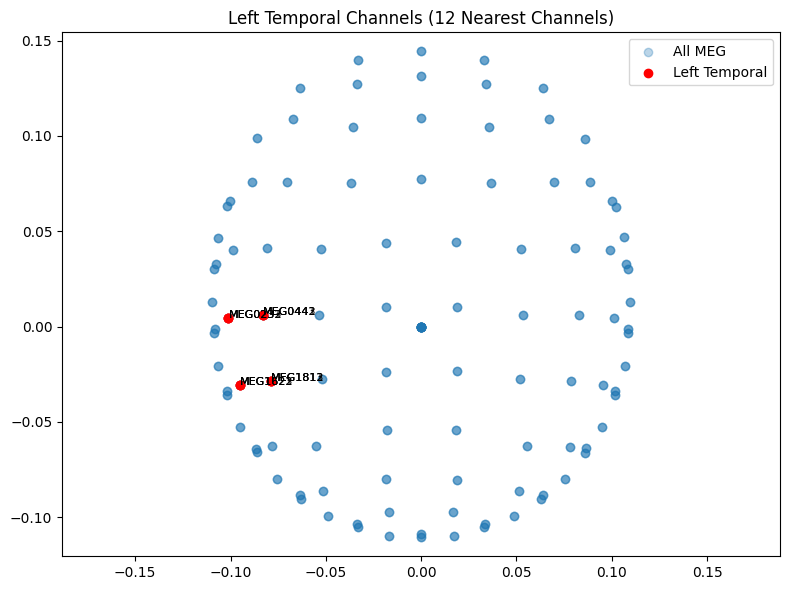

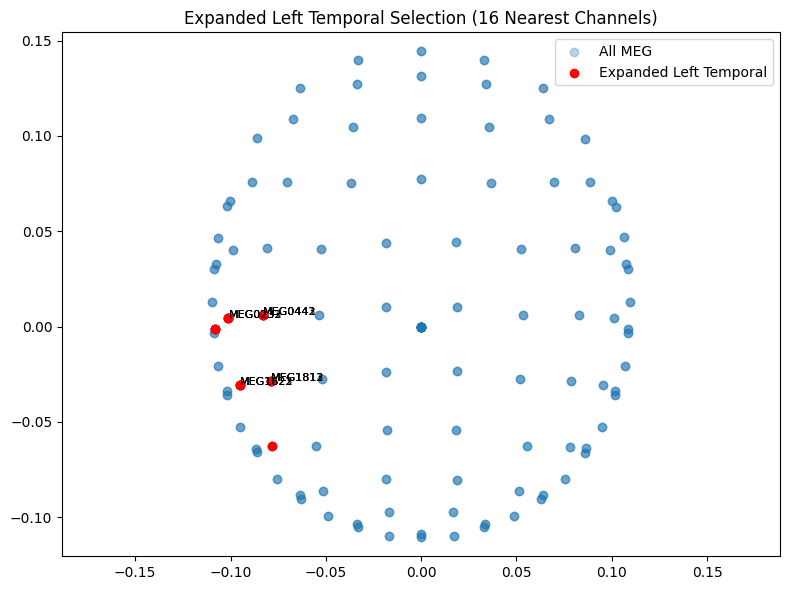

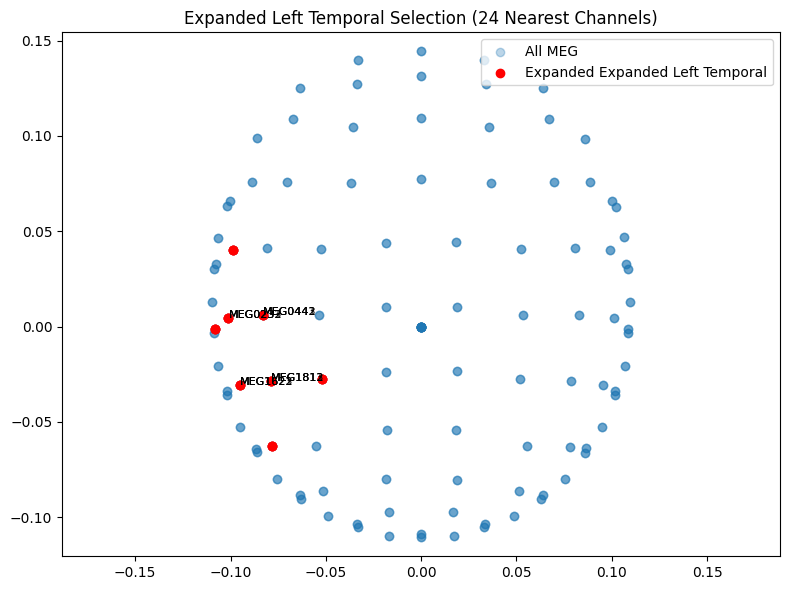

In [ ]:

plt.figure(figsize=(8, 6))
plt.scatter(positions[:, 0], positions[:, 1], label='All MEG', alpha=0.3)
plt.scatter(positions[lt_mask_12, 0], positions[lt_mask, 1], color='red', label='Left Temporal')
for i, name in enumerate(names):
    if lt_mask[i]:
        plt.text(positions[i, 0], positions[i, 1], name, fontsize=8)
plt.title("Left Temporal Channels (12 Nearest Channels)")
plt.axis('equal')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(ch_locs[:, 0], ch_locs[:, 1], label='All MEG', alpha=0.3)
plt.scatter(ch_locs[lt_mask_16, 0], ch_locs[lt_mask_16, 1], color='red', label='Expanded Left Temporal')
for i, name in enumerate(ch_names):
    if lt_mask[i]:
        plt.text(ch_locs[i, 0], ch_locs[i, 1], name, fontsize=8)
plt.title("Expanded Left Temporal Selection (16 Nearest Channels)")
plt.axis('equal')
plt.legend()
plt.tight_layout()
plt.show()

lt_mask2 = [name in expanded_expanded_left_temporal_channels for name in ch_names]

plt.figure(figsize=(8, 6))
plt.scatter(ch_locs[:, 0], ch_locs[:, 1], label='All MEG', alpha=0.3)
plt.scatter(ch_locs[lt_mask_24, 0], ch_locs[lt_mask_24, 1], color='red', label='Expanded Expanded Left Temporal')
for i, name in enumerate(ch_names):
    if lt_mask[i]:
        plt.text(ch_locs[i, 0], ch_locs[i, 1], name, fontsize=8)
plt.title("Expanded Left Temporal Selection (24 Nearest Channels)")
plt.axis('equal')
plt.legend()
plt.tight_layout()
plt.show()



=== Subject M001 ===
📄 M001: 627 valid trials
LogisticRegression   Accuracy: 0.474 ± 0.020


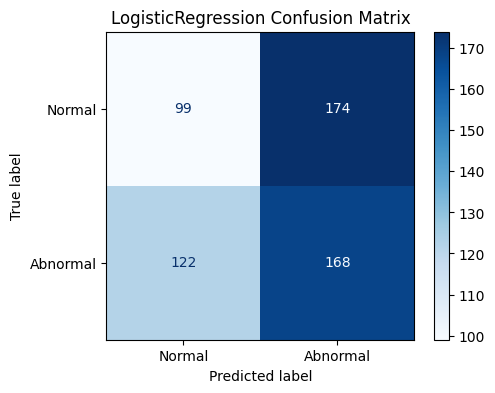

RandomForest         Accuracy: 0.528 ± 0.025


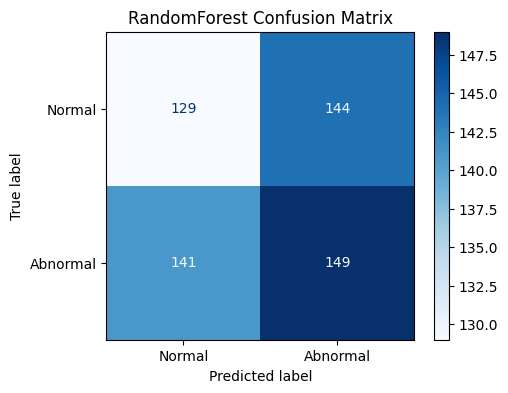

SVM                  Accuracy: 0.476 ± 0.014


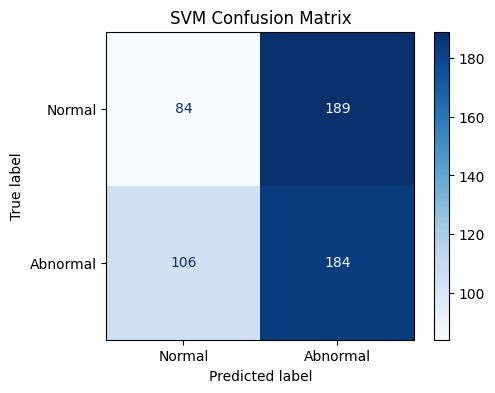

KNN                  Accuracy: 0.560 ± 0.031


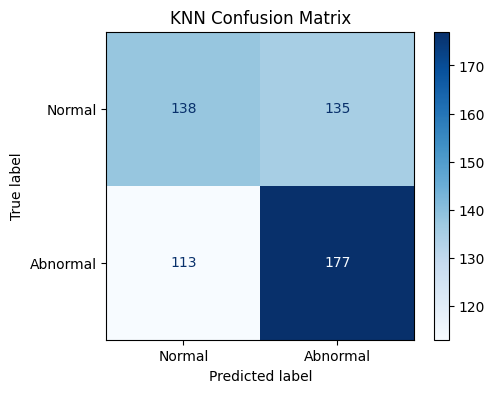

MLP                  Accuracy: 0.485 ± 0.011


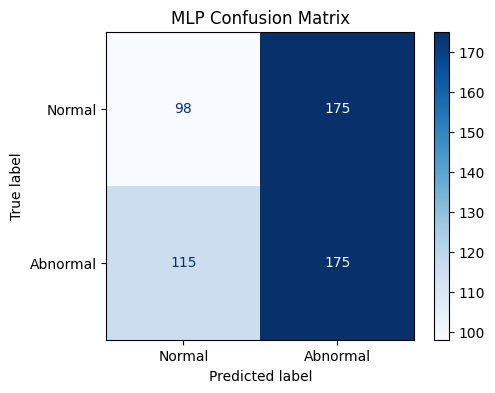

GradientBoosting     Accuracy: 0.495 ± 0.027


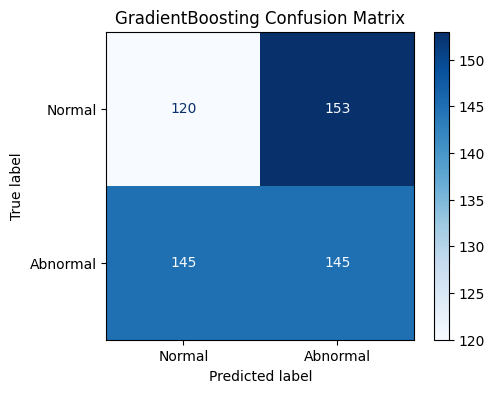


📊 Confusion Matrix (Random Forest):
[[126 147]
 [138 152]]

=== Subject M002 ===
📄 M002: 656 valid trials
LogisticRegression   Accuracy: 0.495 ± 0.015


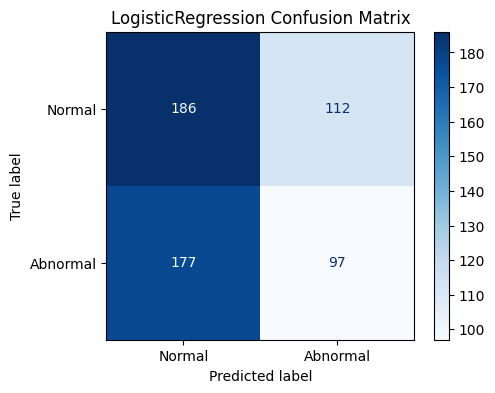

RandomForest         Accuracy: 0.521 ± 0.035


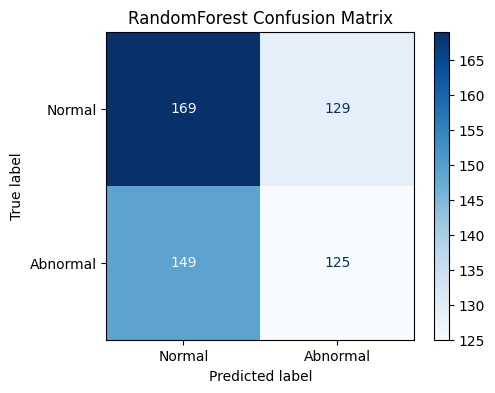

SVM                  Accuracy: 0.488 ± 0.019


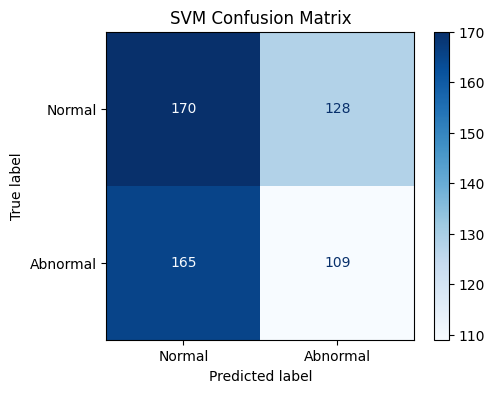

KNN                  Accuracy: 0.516 ± 0.039


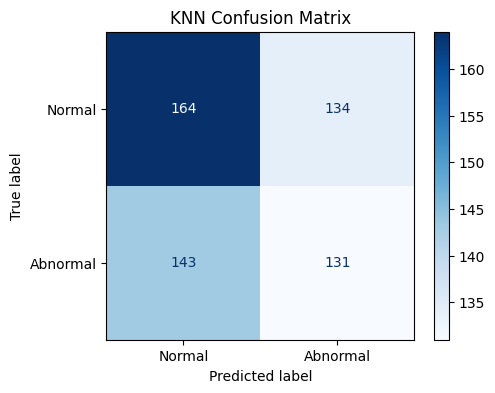

MLP                  Accuracy: 0.498 ± 0.020


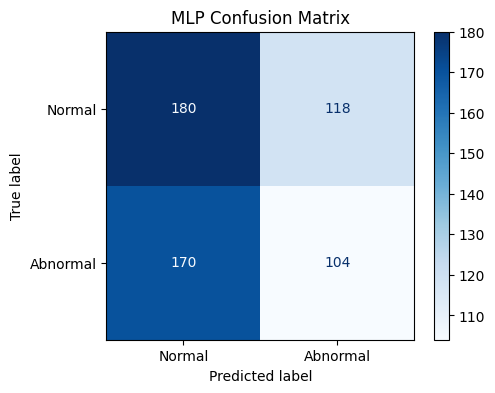

GradientBoosting     Accuracy: 0.519 ± 0.044


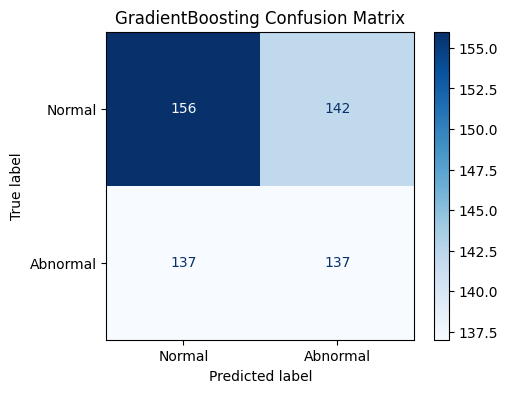


📊 Confusion Matrix (Random Forest):
[[164 134]
 [155 119]]

=== Subject M003 ===


KeyboardInterrupt: 

In [ ]:
import os
import numpy as np
import pandas as pd
import mne
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from scipy.spatial.distance import cdist

import warnings
from sklearn.metrics import ConfusionMatrixDisplay

def extract_aligned_epochs(raw, alignment_df, region_channels, label_field="normality"):
    warnings.filterwarnings("ignore")  # suppress all warnings globally

    sfreq = raw.info['sfreq']
    window_samples = int(0.5 * sfreq)  # 0.5s window
    print(window_samples)
    offset = int(0.2 * sfreq)  # start 0.2s after trigger
    print(offset)

    meg_picks = mne.pick_types(raw.info, meg=True, stim=False, eog=False, exclude='bads')

    X_raw, y = [], []
    for _, row in alignment_df.iterrows():
        if row.get(label_field) not in ["normal", "abnormal"]:
            continue
        if pd.isna(row.get("global_onset")):
            continue

        onset_sample = int(row["global_onset"] * sfreq) + offset
        if onset_sample < 0 or onset_sample + window_samples > raw.n_times:
            continue

        segment = raw.get_data(picks=meg_picks, start=onset_sample, stop=onset_sample + window_samples)
        X_raw.append(segment[np.newaxis, ...])
        y.append(1 if row[label_field] == "abnormal" else 0)

    X_raw = np.concatenate(X_raw, axis=0)
    y = np.array(y)

    region_indices = [raw.ch_names.index(ch) for ch in region_channels if ch in raw.ch_names]
    X_region = X_raw[:, region_indices, :].mean(axis=1)
    return X_region, y, sfreq

from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def evaluate_models(X, y):
    models = {
        "LogisticRegression": LogisticRegression(max_iter=1000),
        "RandomForest": RandomForestClassifier(n_estimators=100),
        "SVM": SVC(kernel='linear', probability=True),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=500),
        "GradientBoosting": GradientBoostingClassifier(n_estimators=100)
    }

    results = {}
    for name, model in models.items():
        clf = make_pipeline(StandardScaler(), model)
        scores = cross_val_score(clf, X, y, cv=5)
        y_pred = cross_val_predict(clf, X, y, cv=5)

        results[name] = (scores.mean(), scores.std())
        print(f"{name:20s} Accuracy: {scores.mean():.3f} ± {scores.std():.3f}")

        cm = confusion_matrix(y, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Abnormal"])
        fig, ax = plt.subplots(figsize=(5, 4))
        disp.plot(cmap="Blues", ax=ax, values_format='d')
        plt.title(f"{name} Confusion Matrix")
        plt.grid(False)
        plt.show()

    return results


# --------- Helper: Load raw and alignment ---------
def load_raw_and_alignment(subject_code):
    import helper

    # Load raw
    base_path = f"/content/drive/MyDrive/Colab Notebooks/MNE/MNE_data/m_{subject_code[1:]}/250414"
    raw_files = [os.path.join(base_path, f"{subject_code}_block{i}_raw.fif") for i in range(8)]
    raw_list = [mne.io.read_raw_fif(f, preload=True, verbose='ERROR') for f in raw_files]
    raw_combined = mne.concatenate_raws(raw_list, on_mismatch='ignore')

    # Load and process CSV
    csv_path = f"/content/drive/MyDrive/Colab Notebooks/MNE/bci-main/src/data/{subject_files[subject_code]}"
    df = pd.read_csv(csv_path)

    df["audio_file"] = df["audio_file"].str.replace("\\", "/", regex=False)
    df["audio_file"] = df["audio_file"].str.replace("../", "../", regex=False)

    tsv_path = "/content/drive/MyDrive/Colab Notebooks/MNE/bci-main/stimuli/demo/*.tsv"
    all_data = helper.stimuli_load(tsv_path)
    meta_df = pd.DataFrame.from_dict(all_data, orient='index').reset_index()
    meta_df.rename(columns={"index": "stimulus"}, inplace=True)
    df = df.merge(meta_df, how="left", left_on="audio_file", right_on="stimulus")

    df["global_onset"] = df["presentation.started"] + df["trigger_word_on.started"]
    df["response_clean"] = pd.to_numeric(df["buttonBox_2.keys"], errors='coerce').fillna(-1).astype(int)
    df["speaker_type"] = df["speaker"].apply(
        lambda s: "bot" if s in {"bot", "bot2"} else ("human" if pd.notna(s) else None)
    )

    def compute_resp_correct(row):
        if row["response_clean"] == -1 or pd.isna(row["tgt_sound"]) or pd.isna(row["sibilants"]):
            return None
        options = ["f", "θ"] if row["sibilants"] == "nonsibilant" else ["s", "ʃ"]
        if 0 <= row["response_clean"] < len(options):
            return row["tgt_sound"] == options[row["response_clean"]]
        return None

    df["resp_correct"] = df.apply(compute_resp_correct, axis=1)
    valid_df = df[df["response_clean"] != -1].copy()
    valid_df = valid_df.sort_values("global_onset").reset_index(drop=True)

    print(f"📄 {subject_code}: {len(valid_df)} valid trials")
    return raw_combined, valid_df


# --------- Select Left Temporal Channels ---------
def get_left_temporal_channels(raw, n_nearest=16):
    ch_names = [ch['ch_name'] for ch in raw.info['chs']]
    ch_locs = np.array([ch['loc'][:3] for ch in raw.info['chs']])

    core = [ch for ch in raw.info['chs'] if ch['loc'][0] < -0.03 and abs(ch['loc'][1]) < 0.04 and 0.02 < ch['loc'][2] < 0.09]
    core_locs = np.array([ch['loc'][:3] for ch in core])
    center = core_locs.mean(axis=0)

    dists = cdist(ch_locs, [center]).flatten()
    nearest_idx = np.argsort(dists)[:n_nearest]
    return [ch_names[i] for i in nearest_idx]

# --------- Subject CSV file map ---------
subject_files = {
    "M001": "M001_main_2025-04-04_14h50.48.761.csv",
    "M002": "M002_main_2025-04-14_13h48.34.684.csv",
    "M003": "M003_main_2025-04-14_15h02.26.451.csv"
}

# --------- Pipeline ---------
def run_pipeline(sid):
    subject_code = f"M00{sid}"
    print(f"\n=== Subject {subject_code} ===")

    raw, alignment_df = load_raw_and_alignment(subject_code)
    region_channels = get_left_temporal_channels(raw, n_nearest=16)
    X, y, sfreq = extract_aligned_epochs(raw, alignment_df, region_channels)

    results = evaluate_models(X, y)

    # 🔍 Confusion Matrix using RandomForest as baseline
    clf = make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=100))
    y_pred = cross_val_predict(clf, X, y, cv=5)
    print("\n📊 Confusion Matrix (Random Forest):")
    print(confusion_matrix(y, y_pred))

    return results

# --------- Run All Subjects ---------
if __name__ == "__main__":
    for sid in [1, 2, 3]:
        run_pipeline(sid)

